# 1. Is the Retail-Plus fall real, or the wobble Kalpa sees every quarter?

**Week 1, Thursday. Chapter 1 of 6.** Wednesday reconciled the two quarters with Finance's books,
and the Retail-Plus fall survived the cleaning, smaller than first reported. This chapter asks
whether that fall is bigger than chance makes on its own, and it starts the day's toolkit with a
coin per member that decides which of the member's two quarters counts as Q1.

> **The client asks.** "Retail-Plus is down, smaller than first reported. Real, or the wobble we see
> every quarter?"
>
> Meera Raghavan, CEO, Kalpa Retail

**Who needs the answer.** Meera decides at Monday's growth review whether the Retail-Plus tier's
fall gets a budget of its own. A wobble read as a real fall funds a fix for nothing, and a real fall
read as a wobble lets the tier drain.

**The questions on the way.**

1. Which of four ways to ask "is it real?" fits 22 members measured twice?
2. How often do coin tosses on five members' cards make a gap of Rs 880?
3. What does the usual wobble look like on Retail-Core?
4. How often does chance alone make a fall as large as Retail-Plus's?
5. What does the share say about the chance that the finding is wrong?
6. Do the textbook paired test and an exact count agree?

**The metric at stake.** Delivered revenue per Retail-Plus member per quarter: the money kept from
each member's delivered orders, with cancelled and returned orders left out, as Monday settled.
Retail-Plus is Kalpa's paid membership tier, where the customers who buy most often sit; the retail
dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, tells its story in more
depth. The file holds the same 22 Retail-Plus members in both quarters, so each member can be
compared with themselves.

**Who else faces it.** Booking.com runs about 25,000 tests a year and more than 1,000 at once, and
by the account of Stefan Thomke, who studied its testing for Harvard Business Review, about nine in
ten of its experiments improve nothing (HBR, 2020, and HBR's podcast, 2019, both checked 30
September 2026). Every change there is read against what chance alone produces before anyone acts.

**Setup.** Find the helper and load the cleaned two quarters. Five helpers start the day's
toolkit: `member_totals` turns orders into one number per member, always in the same member order;
`flip_gaps` keeps each member's two quarters together and tosses a coin per member to decide which
quarter is which; `shuffle_gaps` deals the values of two groups of different customers into two
piles; and `share_at_least` and `share_either` count the chance-only worlds that match the real
gap, in one direction or in both. Every later chapter carries these forward and adds its own.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)

print(len(ORDERS), "orders,", len({o["customer_id"] for o in ORDERS}), "customers, two quarters")

186 orders, 69 customers, two quarters


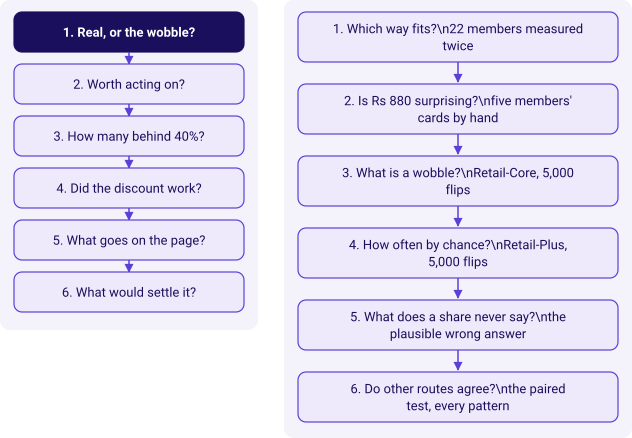

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the wobble?', 'Worth acting on?', 'How many behind 40%?', 'Did the discount work?', 'What goes on the page?', 'What would settle it?'], lit=0, show=False),
    kit.vflow(['1. Which way fits?\\n22 members measured twice', "2. Is Rs 880 surprising?\\nfive members' cards by hand", '3. What is a wobble?\\nRetail-Core, 5,000 flips', '4. How often by chance?\\nRetail-Plus, 5,000 flips', '5. What does a share never say?\\nthe plausible wrong answer', '6. Do other routes agree?\\nthe paired test, every pattern'], show=False),
)

## 1. Which of four ways to ask "is it real?" fits 22 members measured twice?

Four ways a team could answer "is the fall real?" before Monday. What separates them is the design
of the data and what each one assumes about it, so the sizing cell below measures those on this
file.

| Option | What it does | What it needs |
|---|---|---|
| A. Flip each member's own two quarters | A coin per member decides which quarter is which, thousands of times, and counts how often chance makes a fall this large | The members in the same order in both quarters, and a loop |
| B. Pool all 44 totals and deal two piles | Treats the 44 member-quarters as 44 different customers and deals them at random | A loop, and two groups of different people, which this file does not have |
| C. The textbook paired test | One library call on the 22 differences, from a formula for bell-shaped data | A statistics library, and differences that behave like a bell curve |
| D. Wait for Q3 | Look again when another quarter has landed | Thirteen weeks, and a Monday meeting with no answer |

Option,What it stands on here,What it assumes,The error it risks
A. Flip each member's pair,"22 members, one Q1 less Q2 each","if nothing changed, either order of a member's two quarters was as likely",the share moves by 0.004 across five seeds
B. Pool and deal two piles,"44 totals, treated as 44 people",the two quarters hold different customers,"counts the gaps between members as chance; how far that strays rests on how well a member's Q1 predicts their Q2, 0.04 here"
C. Textbook paired test,"22 differences, one call",the average difference behaves like a bell curve,a formula on lumpy totals: 8 of 44 are zero
D. Wait for Q3,22 more member-quarters,nothing new,Monday passes with no answer


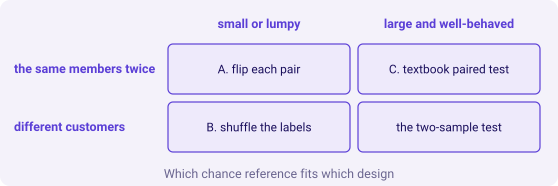

In [3]:
plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)
pairs = len(plus_q1)
zeros = sum(1 for v in plus_q1 + plus_q2 if v == 0)
link = statistics.correlation(plus_q1, plus_q2)            # does a member's Q1 predict their Q2?
wobble = [share_at_least(flip_gaps(plus_q1, plus_q2, 5000, seed=s), real) for s in (1, 2, 3, 4, 5)]
spread = max(wobble) - min(wobble)                          # printed as a spread only: the share waits for section 3

rows = [
    ("A. Flip each member's pair", f"{pairs} members, one Q1 less Q2 each",
     "if nothing changed, either order of a member's two quarters was as likely", f"the share moves by {spread:.3f} across five seeds"),
    ("B. Pool and deal two piles", f"{2 * pairs} totals, treated as {2 * pairs} people",
     "the two quarters hold different customers", f"counts the gaps between members as chance; how far that strays rests on how well a member's Q1 predicts their Q2, {link:.2f} here"),
    ("C. Textbook paired test", f"{pairs} differences, one call",
     "the average difference behaves like a bell curve", f"a formula on lumpy totals: {zeros} of {2 * pairs} are zero"),
    ("D. Wait for Q3", f"{pairs} more member-quarters", "nothing new", "Monday passes with no answer"),
]
kit.table(["Option", "What it stands on here", "What it assumes", "The error it risks"], rows,
          caption="The four options sized on Kalpa's file by what separates them")
kit.matrix(["the same members twice", "different customers"], ["small or lumpy", "large and well-behaved"],
           [["A. flip each pair", "C. textbook paired test"], ["B. shuffle the labels", "the two-sample test"]],
           title="Which chance reference fits which design")
kit.check("the file holds the same 22 members in both quarters, in one order", pairs == len(plus_q2) == 22)
kit.check("8 of the 44 member totals are zero", zeros == 8, f"{zeros}")
kit.check("the flip test's share moves by under 0.005 across five seeds", spread < 0.005, f"{spread:.4f}")

**The best-fit call for Meera's Monday: A, flip each member's own two quarters.** The file holds
the same 22 members in both quarters, so a fair chance reference keeps each member's pair together
and asks only which quarter is which. B treats 22 people as 44 strangers: it counts the gaps between
members as chance, which is the right test for two groups of different customers and the wrong one
here, whatever it prints on this file. C is A's design written as a formula, so it becomes the
second route. D costs a quarter for a question the data can already answer.

**The fact that would change the call.** Thousands of members whose differences behave, which is
what a dashboard at Booking.com's scale sees: C then gives the same answer in one line and is the
house standard. Two groups of different customers, such as Retail-Plus against Retail-Core, switch
the design to B, the label shuffle, which is what chapter 6 runs.

## 2. How often do coin tosses on five members' cards make a gap of Rs 880?

Five members' Q1 and Q2 spend, **invented for the table**, one member per row. Every one of them
spent less in Q2, and the real gap is the Q1 mean less the Q2 mean. If the quarter made no
difference, each member's two cards could have come in either order, so a coin per member decides:
heads keeps the pair as recorded, tails swaps it. One toss of the five coins is one chance-only
world, and its gap is the five signed differences added up and divided by five. The room does this
by hand before this cell runs.

| Member | Q1, Rs | Q2, Rs | Q1 less Q2, Rs |
|---|---|---|---|
| A | 3,400 | 2,400 | 1,000 |
| B | 2,900 | 2,200 | 700 |
| C | 4,100 | 3,100 | 1,000 |
| D | 2,500 | 1,900 | 600 |
| E | 3,800 | 2,700 | 1,100 |

**Predict before you run.** Out of 1,000 tosses of the five coins, how many make a gap of Rs 880 or
more? a) about 500, since half of all gaps are positive; b) about 125; c) about 30; d) none, since
the real gap is the largest a toss can make.

Q1 mean Rs 3,340, Q2 mean Rs 2,460, real gap Rs 880
the first ten tosses: [-40, -480, -440, -360, -240, -440, 160, -40, 480, -640]


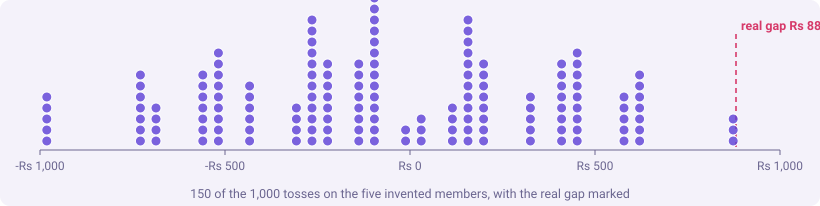

In [4]:
q1_cards = [3400, 2900, 4100, 2500, 3800]
q2_cards = [2400, 2200, 3100, 1900, 2700]                  # the same five members, one row each
card_gap = mean(q1_cards) - mean(q2_cards)
card_gaps = flip_gaps(q1_cards, q2_cards, 1000, seed=2026)
card_share, card_either = share_at_least(card_gaps, card_gap), share_either(card_gaps, card_gap)

print(f"Q1 mean Rs {mean(q1_cards):,.0f}, Q2 mean Rs {mean(q2_cards):,.0f}, real gap Rs {card_gap:,.0f}")
print("the first ten tosses:", [round(g) for g in card_gaps[:10]])
kit.strip(card_gaps[:150], markers=[("real gap", card_gap, "bad")], lo=-1000, hi=1000,
          title="150 of the 1,000 tosses on the five invented members, with the real gap marked")
kit.stats([("1,000", "tosses", "a coin per member each time"),
           (f"{round(card_share * 1000)}", "gaps of Rs 880 or more", "in chance-only worlds"),
           (f"{card_share:.3f}", "the share, one direction", f"{card_either:.3f} counting either way")])

**What happened.** The answer is c. Thirty-five tosses in a thousand reached Rs 880, a share of
0.035, and 64 made a gap of Rs 880 in either direction. Ten hand tosses usually show none, which is
why ten is too few. The exact count explains the number: a gap of Rs 880 needs every member to keep
the order they were recorded in, because swapping any one of them pulls the gap down by at least
Rs 240. Only one of the 32 ways five coins can land does that, so the exact share is 1 in 32, 0.031,
and 2 in 32 counting a gap of Rs 880 either way.

In [5]:
card_diffs = [a - b for a, b in zip(q1_cards, q2_cards)]
patterns = list(itertools.product([1, -1], repeat=len(card_diffs)))
exact_hits = sum(1 for p in patterns if sum(s * d for s, d in zip(p, card_diffs)) >= sum(card_diffs))
kit.check("the real gap on the cards is Rs 880", round(card_gap) == 880, f"{card_gap:,.0f}")
kit.check("35 of 1,000 tosses reach it, with seed 2026", round(card_share * 1000) == 35, f"{card_share:.3f}")
kit.check("exactly 1 of the 32 coin patterns reaches it", exact_hits == 1 and len(patterns) == 32, f"{exact_hits} of {len(patterns)}")

## 3. What does the usual wobble look like on Retail-Core?

Before judging Retail-Plus, see an ordinary quarter. Retail-Core members also spent a little less
in Q2, and the same 34 members sit in both quarters. The measure is the day's: delivered revenue per
member, one number per member, with a zero for a member who had no delivered order that quarter.

**Predict before you run.** Retail-Core fell by about Rs 110 per member. What share of 5,000 flips
will make a fall at least that large? a) under 0.01; b) about 0.05; c) about a third; d) all of them.

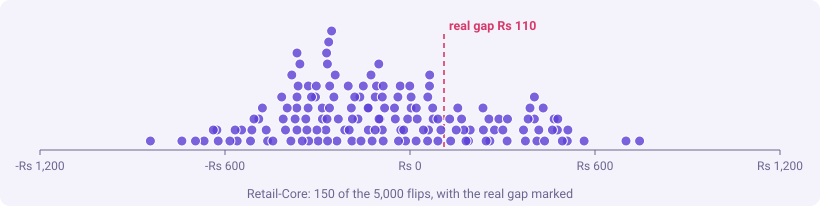

34 members, Q1 Rs 1,509, Q2 Rs 1,399, gap Rs 110; falls at least as large 0.358, a move that large either way 0.723


In [6]:
core_q1, core_q2 = member_totals("Retail-Core", "Q1"), member_totals("Retail-Core", "Q2")
core_gap = mean(core_q1) - mean(core_q2)
core_gaps = flip_gaps(core_q1, core_q2, 5000, seed=2026)
core_share, core_either = share_at_least(core_gaps, core_gap), share_either(core_gaps, core_gap)
kit.strip(core_gaps[:150], markers=[("real gap", core_gap, "bad")], lo=-1200, hi=1200,
          title="Retail-Core: 150 of the 5,000 flips, with the real gap marked")
print(f"{len(core_q1)} members, Q1 Rs {mean(core_q1):,.0f}, Q2 Rs {mean(core_q2):,.0f}, gap Rs {core_gap:,.0f}; "
      f"falls at least as large {core_share:.3f}, a move that large either way {core_either:.3f}")

**What happened.** The answer is c. About a third of chance-only worlds make a fall of Rs 110 or
more (0.358), and about seven in ten make a move that large in either direction (0.723), so
Retail-Core's dip is what Meera calls the usual wobble: the real gap sits inside the pile. Keep this
picture, because it is what "nothing happened" looks like.

In [7]:
kit.check("Retail-Core has 34 members in both quarters", len(core_q1) == len(core_q2) == 34)
kit.check("counting falls only, 1,789 of 5,000 flips reach Retail-Core's gap", round(core_share * 5000) == 1789, f"{core_share:.4f}")
kit.check("counting either way, 3,617 of 5,000 flips reach it", round(core_either * 5000) == 3617, f"{core_either:.4f}")

## 4. How often does chance alone make a fall as large as Retail-Plus's?

The same flips, pointed at the segment in Meera's question.

**Predict before you run.** Compared with Retail-Core's share of about a third, Retail-Plus's share
will be: a) about the same; b) larger, since Retail-Plus is a smaller segment; c) much smaller, if
its fall is bigger than chance makes; d) impossible to compute, since some members have zeros.

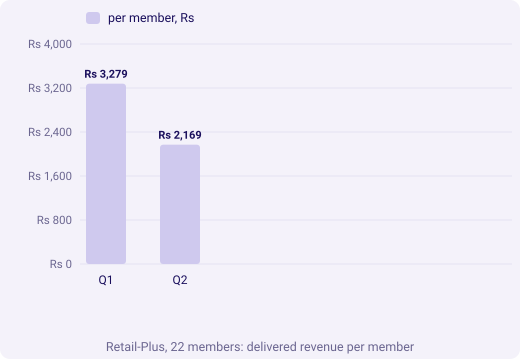

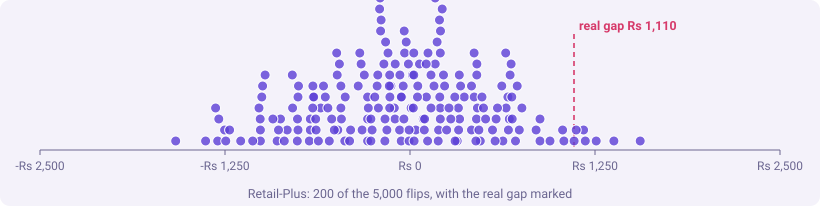

real gap Rs 1,110; falls at least as large: 145 of 5,000, 0.029; a move that large either way: 286 of 5,000, 0.057


In [8]:
plus_gaps = flip_gaps(plus_q1, plus_q2, 5000, seed=2026)
plus_share, plus_either = share_at_least(plus_gaps, real), share_either(plus_gaps, real)
kit.columns(["Q1", "Q2"], [("per member, Rs", [round(mean(plus_q1)), round(mean(plus_q2))])],
            fmt=kit.rupees, width=520, title=f"Retail-Plus, {len(plus_q1)} members: delivered revenue per member")
kit.strip(plus_gaps[:200], markers=[("real gap", real, "bad")], lo=-2500, hi=2500,
          title="Retail-Plus: 200 of the 5,000 flips, with the real gap marked")
print(f"real gap Rs {real:,.0f}; falls at least as large: {round(plus_share * 5000)} of 5,000, {plus_share:.3f}; "
      f"a move that large either way: {round(plus_either * 5000)} of 5,000, {plus_either:.3f}")

**What happened.** The answer is c. Retail-Plus members delivered Rs 3,279 each in Q1 and Rs 2,169
in Q2, a fall of Rs 1,110 per member. Counting falls only, 145 of 5,000 flips made a fall that
large, a share of 0.029; counting a move that large in either direction, 286 did, 0.057. Which of
the two is the p-value is a choice that belongs before the test is run. Meera's question arrived
after the fall had been seen, so the honest report gives both and calls the result borderline:
well outside Retail-Core's third, and at the edge of what chance makes.

In [9]:
kit.check("Retail-Plus has 22 members in both quarters", len(plus_q1) == len(plus_q2) == 22)
kit.check("the Retail-Plus gap is Rs 1,110 a member", round(real) == 1110, f"{real:.1f}")
kit.check("counting falls only, 145 of 5,000 flips reach it, with seed 2026", round(plus_share * 5000) == 145, f"{plus_share:.4f}")
kit.check("counting either way, 286 of 5,000 flips reach it, with seed 2026", round(plus_either * 5000) == 286, f"{plus_either:.4f}")
kit.check("the either-way share is about twice the one-direction share, since the flips are symmetric",
          1.8 < plus_either / plus_share < 2.2, f"{plus_either / plus_share:.2f}")

## 5. What does the share say about the chance that the finding is wrong?

**The plausible wrong answer.** The hurried draft turns the one-direction share straight into a
sentence about being wrong. Here it is, computed exactly the way it gets written, and the decision
it invites is Meera treating the fall as 97 percent certain and funding a fix on that basis.

In [10]:
draft = f"p = {plus_share:.2f}, so there is a {plus_share:.0%} chance we are wrong about the drop."
print(draft)

p = 0.03, so there is a 3% chance we are wrong about the drop.


**Why it is wrong.** Every one of the 5,000 flips was tossed in a world where the quarter made no
difference. The share counts how often *that* world makes a fall this large. It says nothing about
the chance that this finding is wrong, which depends on things the flips never saw: how plausible a
fall was before the data, what else changed, how many segments were tested, and whether the
direction was chosen before or after the fall was seen.

**The check.** Build twenty **invented** segments of twenty members in which nothing changed at
all, each member's two quarters drawn from the same range, and run the same test on each. Any
segment that comes back small is a finding that is wrong for certain, whatever its share says.

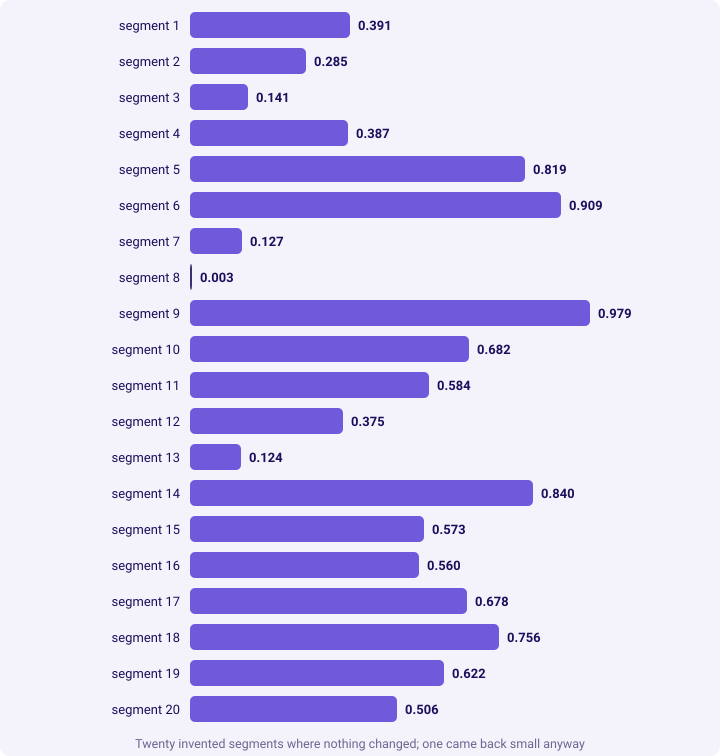

1 of 20 came back at 0.05 or below: [0.003]


In [11]:
invented_shares = []
for s in range(20):
    maker = random.Random(100 + s)                       # invented members, same range both quarters
    values = [maker.randint(1500, 4500) for _ in range(40)]
    q1, q2 = values[:20], values[20:]
    invented_shares.append(share_at_least(flip_gaps(q1, q2, 1000, seed=2026), mean(q1) - mean(q2)))

small = [p for p in invented_shares if p <= 0.05]
kit.bars([(f"segment {i + 1}", round(p, 3)) for i, p in enumerate(invented_shares)],
         lit=[i for i, p in enumerate(invented_shares) if p <= 0.05], fmt=lambda v: f"{v:.3f}",
         title="Twenty invented segments where nothing changed; one came back small anyway")
print(f"{len(small)} of 20 came back at 0.05 or below: {small}")

One invented segment came back at 0.003 although nothing happened in it. Its draft note would say
"a 0.3 percent chance we are wrong", and it would be wrong with certainty.

**The fix.** Say the share, the world it was counted in, both directions, and what they let you
conclude.

If nothing had changed between the quarters, a fall of Rs 1,110 per member or more would turn up in about 3 of every 100 flips, and a move that large either way in about 6; the question came after the fall was seen, so we read it as borderline.


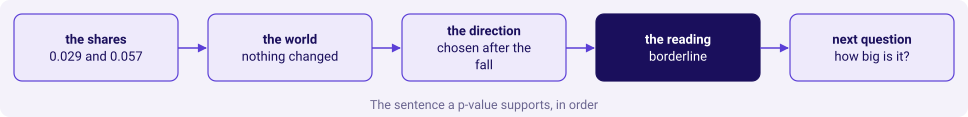

In [12]:
fixed = (f"If nothing had changed between the quarters, a fall of Rs {real:,.0f} per member or more would turn up "
         f"in about {round(plus_share * 100)} of every 100 flips, and a move that large either way in about "
         f"{round(plus_either * 100)}; the question came after the fall was seen, so we read it as borderline.")
print(fixed)
kit.flow(["the shares\n" + f"{plus_share:.3f} and {plus_either:.3f}", "the world\nnothing changed",
          "the direction\nchosen after the fall", "the reading\nborderline", "next question\nhow big is it?"],
         lit=3, title="The sentence a p-value supports, in order")
kit.check("one of twenty no-change segments still came back at 0.05 or below", len(small) == 1, f"{small}")
kit.check("the fixed sentence carries two shares, since both directions were counted", plus_either > plus_share)

What changed: the numbers are the same 0.029 and 0.057, and the claim shrank from "97 percent
certain" to "borderline", which is as far as the evidence goes.

## 6. Do the textbook paired test and an exact count agree?

Option C, run now as the cross-check, beside the exact count of every one of the 4,194,304 ways 22
coins can land. The library call is the paired test a statistics course teaches first; its formula
is for a later week, and today it is a second opinion. The two unpaired numbers, the pooled shuffle
and the textbook two-sample (Welch) test, are shown beside them as what ignoring the pairing gives.

**Predict before you run.** The textbook paired test's p-value for Retail-Plus, counting falls
only, will be: a) about 0.03, the same reading; b) about 0.3, the opposite reading; c) exactly
0.029, since it is the same method; d) impossible, since the totals are not bell-shaped.

Route,Falls only,Either way
"flip each pair, 5,000 flips",0.0290,0.0572
"every coin pattern, 4,194,304",0.0274,0.0549
textbook paired test,0.0275,0.0550
"pooled shuffle, pairing ignored",0.0270,0.0504
"two-sample test, pairing ignored",0.0265,0.0530


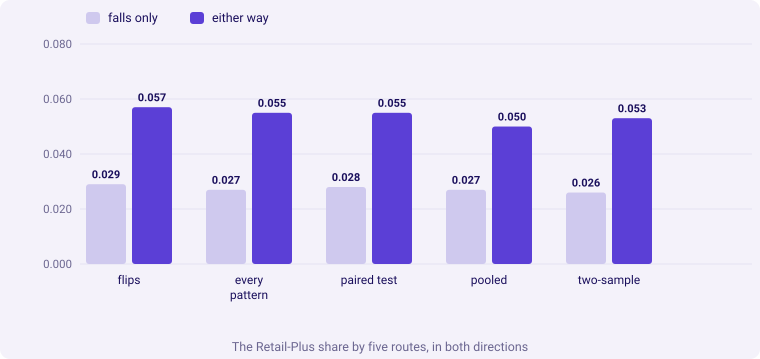

paired t = 2.03 on 21 degrees of freedom


In [13]:
from scipy import stats                                  # the textbook route, named today and taught later
paired_one = stats.ttest_rel(plus_q1, plus_q2, alternative="greater").pvalue
paired_two = stats.ttest_rel(plus_q1, plus_q2).pvalue

diffs = [a - b for a, b in zip(plus_q1, plus_q2)]
counts = {0: 1}                                          # every coin pattern, tallied by the sum it gives
for d in diffs:
    step = {}
    for total, n in counts.items():
        step[total + d] = step.get(total + d, 0) + n
        step[total - d] = step.get(total - d, 0) + n
    counts = step
patterns = 2 ** len(diffs)
exact_one = sum(n for total, n in counts.items() if total >= sum(diffs)) / patterns
exact_two = sum(n for total, n in counts.items() if abs(total) >= sum(diffs)) / patterns

pooled = shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
pooled_one, pooled_two = share_at_least(pooled, real), share_either(pooled, real)
welch_one = stats.ttest_ind(plus_q1, plus_q2, equal_var=False, alternative="greater").pvalue
welch_two = stats.ttest_ind(plus_q1, plus_q2, equal_var=False).pvalue

routes = [("flip each pair, 5,000 flips", plus_share, plus_either),
          (f"every coin pattern, {patterns:,}", exact_one, exact_two),
          ("textbook paired test", paired_one, paired_two),
          ("pooled shuffle, pairing ignored", pooled_one, pooled_two),
          ("two-sample test, pairing ignored", welch_one, welch_two)]
kit.table(["Route", "Falls only", "Either way"], [(r, f"{a:.4f}", f"{b:.4f}") for r, a, b in routes],
          caption="Retail-Plus by five routes: the first three keep each member's pair, the last two ignore it")
kit.columns(["flips", "every pattern", "paired test", "pooled", "two-sample"],
            [("falls only", [round(a, 3) for _, a, _ in routes]), ("either way", [round(b, 3) for _, _, b in routes])],
            fmt=lambda v: f"{v:.3f}", width=760, title="The Retail-Plus share by five routes, in both directions")
print(f"paired t = {stats.ttest_rel(plus_q1, plus_q2).statistic:.2f} on {len(diffs) - 1} degrees of freedom")
kit.check("the three paired routes agree on falls only within 0.002",
          max(plus_share, exact_one, paired_one) - min(plus_share, exact_one, paired_one) < 0.002,
          f"{plus_share:.4f}, {exact_one:.4f}, {paired_one:.4f}")
kit.check("the three paired routes agree either way within 0.003",
          max(plus_either, exact_two, paired_two) - min(plus_either, exact_two, paired_two) < 0.003,
          f"{plus_either:.4f}, {exact_two:.4f}, {paired_two:.4f}")
kit.check("on this file, ignoring the pairing moves the share by under 0.005", abs(pooled_one - plus_share) < 0.005,
          f"{pooled_one:.4f} against {plus_share:.4f}")

**What happened.** The answer is a. The textbook paired test says 0.0275 counting falls only and
0.055 either way, the exact count of every coin pattern says 0.0274 and 0.0549, and the flips said
0.029 and 0.057: three routes, one borderline reading. The unpaired numbers sit close here, 0.027
from the pooled shuffle and 0.026 from the two-sample test, because a member's Q1 spend barely
predicts their Q2 spend in this file (0.04). On a tier where heavy buyers stay heavy, pooling would
count the gaps between members as chance, sit far higher, and could miss a real fall; the extras
sheet shows one. **When to switch.** Use the textbook paired call when the members number in the
thousands and a team standard expects it; keep the flips when the members are few or the totals
lumpy, or when the person reading the answer needs to see how it was made.

> **Kavya's review.** "Retail-Core's third is the wobble. Retail-Plus sits at about 3 in 100
> counting falls and 6 in 100 either way, three routes that keep each member's pair agree, and you
> said which direction you counted and why. Borderline is an honest answer. Now tell me how much
> money it is."

### In the interview: what does p = 0.03 mean, and which test would you run for Monday?

**[S] What does p = 0.03 mean, and not mean?** "It means that if there were no real difference, a
difference at least as large as the one we saw, in the direction we saw, would turn up about 3 times
in 100 by chance alone; counting either direction it would be about 6 in 100, and I say which I
counted and whether I chose it before seeing the data. It does not mean a 3 percent chance the
finding is wrong, and it says nothing about whether the effect is large or worth acting on." The
interviewer is listening for the conditional, "if there were no difference", and for the refusal to
call it the probability of being wrong.

**[S] How do you know whether a change in a metric is significant?** "I build a reference for what
chance alone does, and the design of the data decides how. When the same customers are measured
twice, I keep each customer's two numbers together and flip which is which at random; when the two
groups are different customers, I shuffle the group labels. Then I count how often chance makes a
change as large as the real one, in one direction and in both, check the count behind it, and size
it in money, because significant only means larger than noise." A sharp follow-up: why not pool the
two quarters? Pooling counts the gaps between members as chance. Here it happens to land close,
because Q1 barely predicts Q2; on a tier where heavy buyers stay heavy, it would overstate chance.

**[D] Four ways to ask whether a fall is real: which do you run for a CEO's Monday, and what would
make you switch?** "The same 22 members sit in both quarters, so I flip each member's pair: it
respects the design, and I can show it with cards. I cross-check with the textbook paired test,
which becomes the default on thousands of well-behaved members. Pooling the 44 totals treats 22
people as 44 and is the right test only for different customers. I would wait a quarter only if
both routes came back unclear, because then more data is the only thing that helps."

### Depth: should the share count falls only, or a move either way?

The chapter counted both directions because the question arrived after the fall was seen. Had
Meera asked before Q2 closed, "is Retail-Plus falling?", counting falls only would have been
decided before the test, and 0.029 would carry the reading alone. The rule the glossary keeps: the
direction is decided before the test is run. The flips move a little with the seed, in both
directions, and the reading never does.

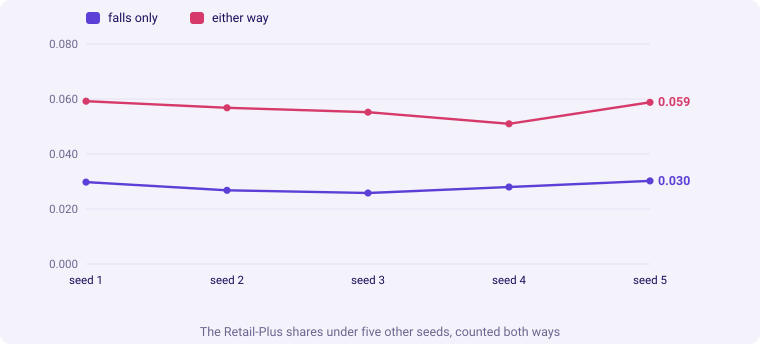

falls only [0.0298, 0.0268, 0.0258, 0.028, 0.0302]; either way [0.0592, 0.0568, 0.0552, 0.051, 0.0588]


In [14]:
seeds = (1, 2, 3, 4, 5)
one_way = [round(share_at_least(flip_gaps(plus_q1, plus_q2, 5000, seed=s), real), 4) for s in seeds]
both_ways = [round(share_either(flip_gaps(plus_q1, plus_q2, 5000, seed=s), real), 4) for s in seeds]
kit.line([f"seed {s}" for s in seeds], [("falls only", one_way, "plain"), ("either way", both_ways, "bad")], lo=0,
         fmt=lambda v: f"{v:.3f}", title="The Retail-Plus shares under five other seeds, counted both ways")
print(f"falls only {one_way}; either way {both_ways}")
kit.check("across five seeds, falls only stays between 0.025 and 0.031", all(0.025 <= s <= 0.031 for s in one_way), f"{one_way}")
kit.check("across five seeds, either way stays between 0.050 and 0.060", all(0.050 <= s <= 0.060 for s in both_ways), f"{both_ways}")

## So is the Retail-Plus fall real, or the wobble Kalpa sees every quarter?

1. Flip each member's own pair, because the same 22 members sit in both quarters and 8 of their 44
   totals are zero; the textbook paired test is the second route.
2. On the five invented members, 35 of 1,000 tosses reach Rs 880 and exactly 1 of the 32 coin
   patterns does, so ten hand tosses are too few to measure a share.
3. Retail-Core's fall of Rs 110 a member turns up in 0.358 of 5,000 flips counting falls and 0.723
   either way, which is the usual wobble.
4. Retail-Plus fell Rs 1,110 a member, from Rs 3,279 to Rs 2,169: 145 of 5,000 flips (0.029) make a
   fall that large, and 286 (0.057) a move that large either way.
5. Nothing: the share was counted in worlds where nothing changed, and one of twenty invented
   no-change segments came back at 0.003.
6. Yes: counting every one of the 4,194,304 coin patterns gives 0.027 and 0.055, and the textbook
   paired test 0.0275 and 0.055.

The fall is borderline. It sits well outside Retail-Core's wobble and at the edge of what chance
makes, and both directions go in the note because Meera asked after the fall was seen. Chapter 2
asks how much money it is.

In [15]:
kit.check_summary()
print("Next: chapter 2. The fall is borderline against chance; is it worth acting on?")

Next: chapter 2. The fall is borderline against chance; is it worth acting on?
